# Sales Forecasting with Oil Price and Store Data

This project builds a simple machine learning forecasting pipeline for daily sales.

The main goal is to predict short-term sales by combining:
- past sales patterns
- store information
- promotions
- transactions
- holidays
- oil price

## Project Motivation

Sales forecasting is important for inventory planning, staffing, and promotion decisions.  
In retail data, sales are not affected by only one factor. They can change because of time patterns, holidays, promotions, customer traffic, and external economic signals such as oil price.

In this project, I use the Favorita grocery sales dataset to answer this question:

**Can we use historical sales and external features to predict the next 30 days of sales?**

Instead of trying to build a very complex model immediately, I compare several models and focus on understanding how feature engineering improves forecasting performance.

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optional: LightGBM
try:
    from lightgbm import LGBMRegressor
    lightgbm_available = True
except ImportError:
    lightgbm_available = False
    print("LightGBM is not installed. The notebook will use Gradient Boosting instead.")

pd.set_option("display.max_columns", 100)

## Load the Data

The project uses multiple CSV files:
- `train.csv`: historical daily sales
- `test.csv`: future dates for prediction
- `stores.csv`: store metadata
- `transactions.csv`: daily store transactions
- `oil.csv`: daily oil price
- `holidays_events.csv`: holiday and event calendar

For a clean and runnable portfolio project, I focus on **Store 16** as a case study.  
This keeps the notebook fast enough to run on a laptop while still showing the full forecasting workflow.

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
stores = pd.read_csv("stores.csv")
transactions = pd.read_csv("transactions.csv")
oil = pd.read_csv("oil.csv")
holidays = pd.read_csv("holidays_events.csv")

print("train:", train.shape)
print("test:", test.shape)
print("stores:", stores.shape)
print("transactions:", transactions.shape)
print("oil:", oil.shape)
print("holidays:", holidays.shape)

train: (3000888, 6)
test: (28512, 5)
stores: (54, 5)
transactions: (83488, 3)
oil: (1218, 2)
holidays: (350, 6)


In [3]:
# Convert date columns to datetime
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])
transactions["date"] = pd.to_datetime(transactions["date"])
oil["date"] = pd.to_datetime(oil["date"])
holidays["date"] = pd.to_datetime(holidays["date"])

train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


## Data Cleaning and Merging

The original data is split across several files, so the first step is to combine them.

Main cleaning decisions:
- Convert all date columns to datetime format.
- Fill missing oil prices using time-series interpolation.
- Merge store metadata by `store_nbr`.
- Merge transactions by `date` and `store_nbr`.
- Create a simple holiday indicator.
- Keep Store 16 for this project case study.

In [4]:
# Fill missing oil prices
oil = oil.sort_values("date").copy()
oil["dcoilwtico"] = oil["dcoilwtico"].interpolate(method="linear")
oil["dcoilwtico"] = oil["dcoilwtico"].ffill().bfill()

# Make a simple holiday indicator
holiday_dates = holidays.loc[holidays["transferred"] == False, "date"].drop_duplicates()
holiday_df = pd.DataFrame({"date": holiday_dates, "is_holiday": 1})

# Focus on Store 16 for a clear case study
store_num = 16
store_train = train[train["store_nbr"] == store_num].copy()

# Merge data
store_train = store_train.merge(stores, on="store_nbr", how="left")
store_train = store_train.merge(transactions, on=["date", "store_nbr"], how="left")
store_train = store_train.merge(oil, on="date", how="left")
store_train = store_train.merge(holiday_df, on="date", how="left")

# Fill missing values after merge
store_train["transactions"] = store_train["transactions"].fillna(0)
store_train["is_holiday"] = store_train["is_holiday"].fillna(0)

store_train.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,dcoilwtico,is_holiday
0,231,2013-01-01,16,AUTOMOTIVE,0.0,0,Santo Domingo,Santo Domingo de los Tsachilas,C,3,0.0,93.14,1.0
1,232,2013-01-01,16,BABY CARE,0.0,0,Santo Domingo,Santo Domingo de los Tsachilas,C,3,0.0,93.14,1.0
2,233,2013-01-01,16,BEAUTY,0.0,0,Santo Domingo,Santo Domingo de los Tsachilas,C,3,0.0,93.14,1.0
3,234,2013-01-01,16,BEVERAGES,0.0,0,Santo Domingo,Santo Domingo de los Tsachilas,C,3,0.0,93.14,1.0
4,235,2013-01-01,16,BOOKS,0.0,0,Santo Domingo,Santo Domingo de los Tsachilas,C,3,0.0,93.14,1.0


In [5]:
print(store_train.shape)
print(store_train.isna().sum())

(55572, 13)
id                  0
date                0
store_nbr           0
family              0
sales               0
onpromotion         0
city                0
state               0
type                0
cluster             0
transactions        0
dcoilwtico      15873
is_holiday          0
dtype: int64


## Exploratory Data Analysis

Before modeling, I checked basic patterns in the data.

The most useful questions were:
- Do sales show clear time patterns?
- Are transactions related to sales?
- Does oil price have a visible relationship with sales?
- Are weekends or holidays important?

In [6]:
# Daily total sales and transactions for Store 16
daily = (
    store_train
    .groupby("date", as_index=False)
    .agg({
        "sales": "sum",
        "transactions": "mean",
        "dcoilwtico": "mean",
        "is_holiday": "max"
    })
)

daily.head()

,date,sales,transactions,dcoilwtico,is_holiday
0,2013-01-01,0.000,0.0,93.14,1.0
1,2013-01-02,6242.572,1167.0,93.14,0.0
2,2013-01-03,5316.415,1101.0,92.97,0.0
3,2013-01-04,4616.990,977.0,93.12,0.0
4,2013-01-05,6014.655,1109.0,NaN,1.0


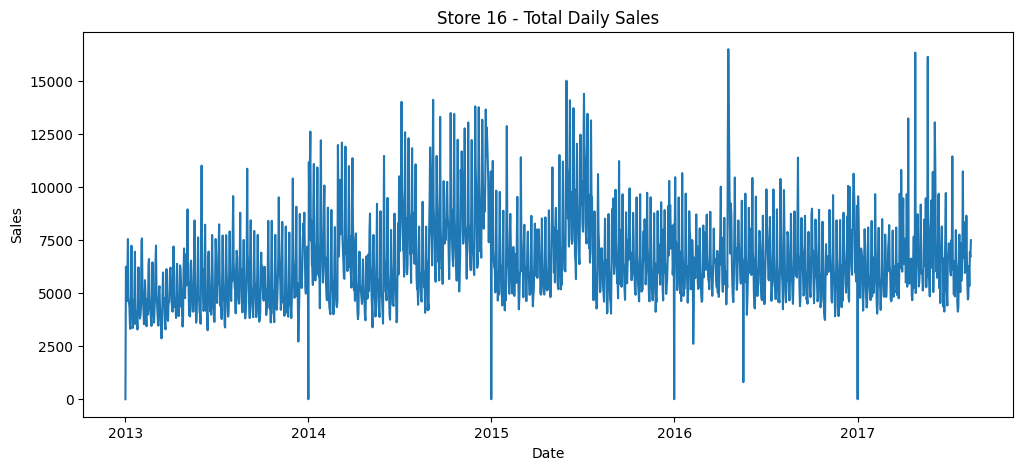

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(daily["date"], daily["sales"])
plt.title("Store 16 - Total Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

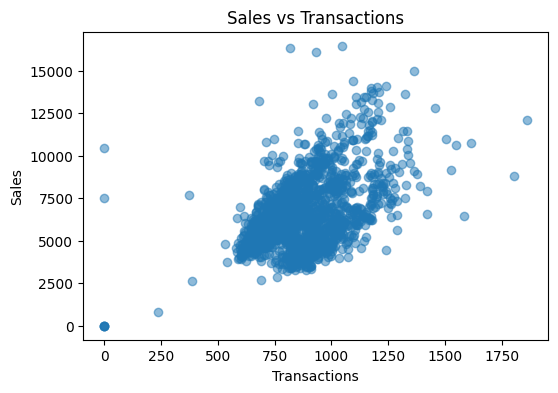

In [8]:
plt.figure(figsize=(6, 4))
plt.scatter(daily["transactions"], daily["sales"], alpha=0.5)
plt.title("Sales vs Transactions")
plt.xlabel("Transactions")
plt.ylabel("Sales")
plt.show()

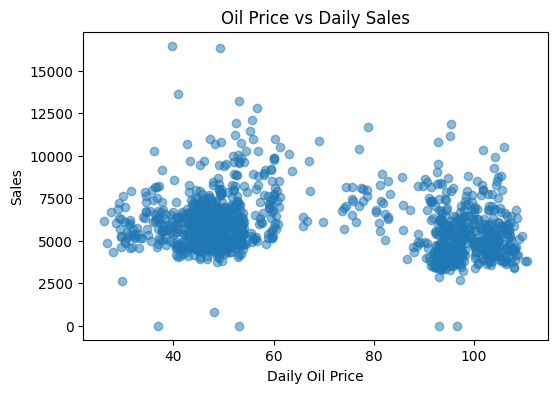

In [9]:
plt.figure(figsize=(6, 4))
plt.scatter(daily["dcoilwtico"], daily["sales"], alpha=0.5)
plt.title("Oil Price vs Daily Sales")
plt.xlabel("Daily Oil Price")
plt.ylabel("Sales")
plt.show()

### EDA Notes

The transaction plot shows a clear positive relationship with sales.  
This makes sense because transaction count is a direct signal of store traffic.

The oil price relationship is less direct. Oil price may still be useful because it can reflect broader economic conditions, but it should not be expected to explain sales by itself.

Because retail data has strong time patterns, the next step is to create time-based and lag-based features.

## Feature Engineering

Regular machine learning models do not automatically understand time order.  
For example, Random Forest or Linear Regression treats each row as independent unless we manually give it time information.

To make the data useful for forecasting, I added:

**Time features**
- year
- month
- day
- day of week
- weekend indicator

**Lag features**
- sales from 1 day ago
- sales from 7 days ago
- sales from 14 days ago
- sales from 28 days ago

**Rolling features**
- 7-day rolling mean
- 14-day rolling mean
- 28-day rolling mean

These features give the model a simple form of memory.

In [10]:
def make_features(df):
    df = df.sort_values(["family", "date"]).copy()

    # Time features
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    # Lag features by product family
    for lag in [1, 7, 14, 28]:
        df[f"lag_{lag}"] = df.groupby("family")["sales"].shift(lag)

    # Rolling features by product family
    for window in [7, 14, 28]:
        df[f"rolling_mean_{window}"] = (
            df.groupby("family")["sales"]
            .shift(1)
            .rolling(window)
            .mean()
            .reset_index(level=0, drop=True)
        )

    return df

model_df = make_features(store_train)

# Drop rows where lag/rolling features are missing
model_df = model_df.dropna().copy()

model_df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,dcoilwtico,is_holiday,year,month,day,dayofweek,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28
924,50127,2013-01-29,16,AUTOMOTIVE,2.0,0,Santo Domingo,Santo Domingo de los Tsachilas,C,3,995.0,97.62,0.0,2013,1,29,1,0,4.0,3.0,4.0,0.0,10.285714,8.642857,8.714286
957,51909,2013-01-30,16,AUTOMOTIVE,5.0,0,Santo Domingo,Santo Domingo de los Tsachilas,C,3,885.0,97.98,0.0,2013,1,30,2,0,2.0,6.0,3.0,5.0,5.714286,5.142857,5.000000
990,53691,2013-01-31,16,AUTOMOTIVE,2.0,0,Santo Domingo,Santo Domingo de los Tsachilas,C,3,886.0,97.65,0.0,2013,1,31,3,0,5.0,3.0,4.0,5.0,4.571429,4.214286,5.500000
1023,55473,2013-02-01,16,AUTOMOTIVE,4.0,0,Santo Domingo,Santo Domingo de los Tsachilas,C,3,909.0,97.46,0.0,2013,2,1,4,0,2.0,5.0,2.0,2.0,6.428571,5.928571,4.428571
1122,60819,2013-02-04,16,AUTOMOTIVE,5.0,0,Santo Domingo,Santo Domingo de los Tsachilas,C,3,1079.0,96.21,0.0,2013,2,4,0,0,7.0,4.0,2.0,5.0,6.857143,5.642857,6.428571


## Prepare Modeling Data

The goal is to predict `sales`.

For categorical variables such as product family, city, and store type, I use one-hot encoding with `pd.get_dummies()`.  
This is simple and easy to understand for a student-level project.

In [11]:
target = "sales"

feature_cols = [
    "onpromotion", "transactions", "dcoilwtico", "is_holiday",
    "year", "month", "day", "dayofweek", "is_weekend",
    "lag_1", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28",
    "family", "city", "state", "type", "cluster"
]

data_for_model = model_df[feature_cols + [target, "date"]].copy()

# One-hot encode categorical columns
data_for_model = pd.get_dummies(
    data_for_model,
    columns=["family", "city", "state", "type"],
    drop_first=True
)

data_for_model.head()

,onpromotion,transactions,dcoilwtico,is_holiday,year,month,day,dayofweek,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,cluster,sales,date,family_BABY CARE,family_BEAUTY,family_BEVERAGES,family_BOOKS,family_BREAD/BAKERY,family_CELEBRATION,family_CLEANING,family_DAIRY,family_DELI,family_EGGS,family_FROZEN FOODS,family_GROCERY I,family_GROCERY II,family_HARDWARE,family_HOME AND KITCHEN I,family_HOME AND KITCHEN II,family_HOME APPLIANCES,family_HOME CARE,family_LADIESWEAR,family_LAWN AND GARDEN,family_LINGERIE,"family_LIQUOR,WINE,BEER",family_MAGAZINES,family_MEATS,family_PERSONAL CARE,family_PET SUPPLIES,family_PLAYERS AND ELECTRONICS,family_POULTRY,family_PREPARED FOODS,family_PRODUCE,family_SCHOOL AND OFFICE SUPPLIES,family_SEAFOOD
924,0,995.0,97.62,0.0,2013,1,29,1,0,4.0,3.0,4.0,0.0,10.285714,8.642857,8.714286,3,2.0,2013-01-29,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
957,0,885.0,97.98,0.0,2013,1,30,2,0,2.0,6.0,3.0,5.0,5.714286,5.142857,5.000000,3,5.0,2013-01-30,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
990,0,886.0,97.65,0.0,2013,1,31,3,0,5.0,3.0,4.0,5.0,4.571429,4.214286,5.500000,3,2.0,2013-01-31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1023,0,909.0,97.46,0.0,2013,2,1,4,0,2.0,5.0,2.0,2.0,6.428571,5.928571,4.428571,3,4.0,2013-02-01,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1122,0,1079.0,96.21,0.0,2013,2,4,0,0,7.0,4.0,2.0,5.0,6.857143,5.642857,6.428571,3,5.0,2013-02-04,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Train/Test Split

Because this is a time series forecasting problem, I do not randomly split the data.

Instead, I use the last 30 days as the validation period.  
This better matches the real task of predicting future sales.

In [12]:
last_date = data_for_model["date"].max()
valid_start = last_date - pd.Timedelta(days=29)

train_df = data_for_model[data_for_model["date"] < valid_start].copy()
valid_df = data_for_model[data_for_model["date"] >= valid_start].copy()

X_train = train_df.drop(columns=[target, "date"])
y_train = train_df[target]

X_valid = valid_df.drop(columns=[target, "date"])
y_valid = valid_df[target]

print("Training dates:", train_df["date"].min(), "to", train_df["date"].max())
print("Validation dates:", valid_df["date"].min(), "to", valid_df["date"].max())
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

Training dates: 2013-01-29 00:00:00 to 2017-07-14 00:00:00
Validation dates: 2017-07-17 00:00:00 to 2017-08-15 00:00:00
X_train: (37671, 49)
X_valid: (726, 49)


## Model Comparison

I compared several models:

1. **Naive baseline**: uses `lag_1` as prediction  
2. **Linear Regression**: simple interpretable model  
3. **Ridge Regression**: linear model with regularization  
4. **Random Forest**: nonlinear tree-based model  
5. **LightGBM or Gradient Boosting**: boosting model if available

This comparison shows the process of trying multiple approaches instead of choosing one model immediately.

In [16]:
def check_model(name, pred, actual):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

X_train = X_train.copy()
X_valid = X_valid.copy()

X_train.columns = (
    X_train.columns
    .astype(str)
    .str.replace(r"[^A-Za-z0-9_]", "_", regex=True)
)

X_valid.columns = X_train.columns

# Naive baseline
naive_pred = X_valid["lag_1"]
results.append(check_model("Naive lag_1", naive_pred, y_valid))

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_valid)
results.append(check_model("Linear Regression", lr_pred, y_valid))

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_valid)
results.append(check_model("Ridge Regression", ridge_pred, y_valid))

# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_valid)
results.append(check_model("Random Forest", rf_pred, y_valid))

# LightGBM if installed, otherwise Gradient Boosting
if lightgbm_available:

    boost_model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42
    )

    boost_name = "LightGBM"

else:

    boost_model = GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    boost_name = "Gradient Boosting"

boost_model.fit(X_train, y_train)
boost_pred = boost_model.predict(X_valid)
results.append(check_model(boost_name, boost_pred, y_valid))
results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000814 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2517
[LightGBM] [Info] Number of data points in the train set: 37671, number of used features: 47
[LightGBM] [Info] Start training from score 178.672483


,Model,MAE,RMSE,R2
4,LightGBM,38.135300,125.803644,0.919740
2,Ridge Regression,46.777589,127.682168,0.917325
1,Linear Regression,46.802183,127.731400,0.917262
3,Random Forest,38.445363,168.786162,0.855528
0,Naive lag_1,59.501777,195.190208,0.806791


## Validation Visualization

The model comparison table gives numerical performance, but plots help show whether the model captures the overall movement.

I visualize the best model from the validation comparison.

Best model: LightGBM


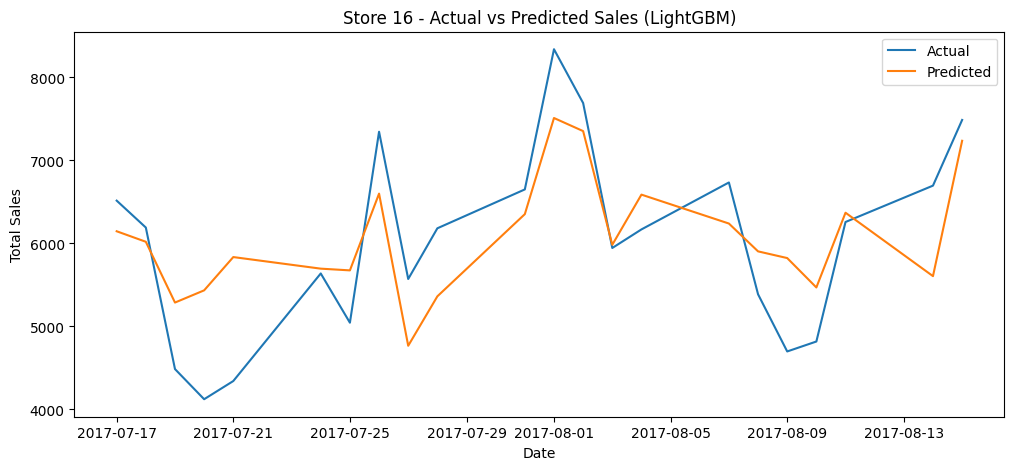

In [17]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

if best_model_name == "Naive lag_1":
    best_pred = naive_pred
elif best_model_name == "Linear Regression":
    best_pred = lr_pred
elif best_model_name == "Ridge Regression":
    best_pred = ridge_pred
elif best_model_name == "Random Forest":
    best_pred = rf_pred
else:
    best_pred = boost_pred

plot_df = valid_df[["date"]].copy()
plot_df["actual"] = y_valid.values
plot_df["predicted"] = best_pred

daily_plot = plot_df.groupby("date", as_index=False)[["actual", "predicted"]].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_plot["date"], daily_plot["actual"], label="Actual")
plt.plot(daily_plot["date"], daily_plot["predicted"], label="Predicted")
plt.title(f"Store 16 - Actual vs Predicted Sales ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.show()

## Feature Importance

For tree-based models, feature importance helps explain which variables the model relied on most.

This is useful because forecasting models should not only produce predictions.  
They should also help us understand what signals mattered.

In [18]:
# Use Random Forest feature importance because it is easy to interpret
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(15)

importance_df

,feature,importance
9,lag_1,0.615754
10,lag_7,0.191996
28,family_GROCERY_I,0.080630
11,lag_14,0.047333
1,transactions,0.026128
6,day,0.006499
0,onpromotion,0.005724
2,dcoilwtico,0.005246
12,lag_28,0.004934
4,year,0.003122


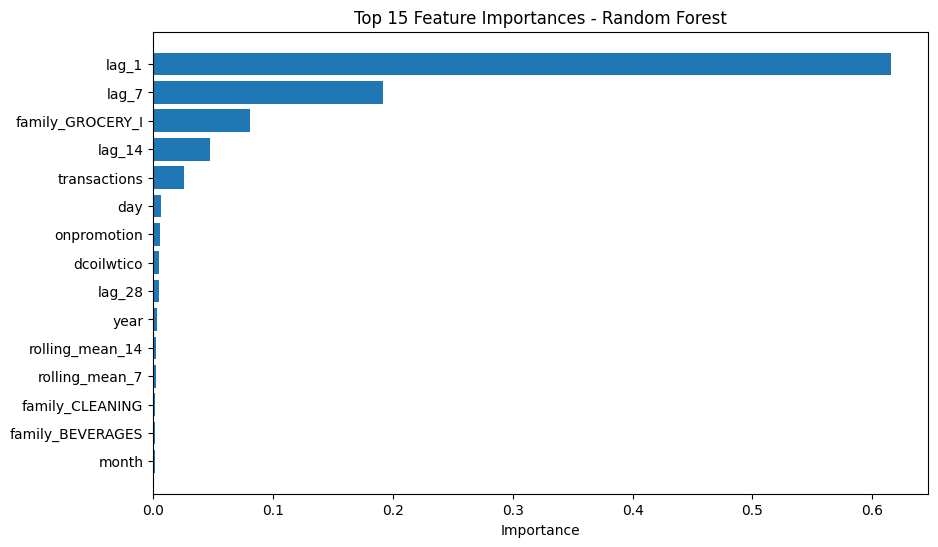

In [19]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

## Key Insights

Main findings from this project:

1. **Lag features were very important.**  
   Recent sales history gave the model useful memory.

2. **Transactions were strongly related to sales.**  
   Store traffic is one of the clearest sales drivers.

3. **Time features helped capture seasonality.**  
   Month, day of week, and weekend indicators helped the model learn repeated retail patterns.

4. **Oil price was less directly related to daily sales.**  
   It may still be useful as an external economic feature, but it was not the strongest signal.

5. **Tree-based models performed better than simple linear models.**  
   This suggests that the relationship between sales and predictors is nonlinear.

## Limitations

This project is a clean student-level version of a larger forecasting problem.  
There are several limitations:

- The notebook focuses on Store 16 as a case study to keep runtime manageable.
- Transactions are useful but may not always be available for future dates.
- Promotion information is simplified.
- Random Forest and boosting models do not directly model time-series dependence unless lag features are added.
- External factors such as weather, local events, or broader economic indicators were not included.

## Final Summary

This project explored retail sales forecasting using machine learning models and feature engineering on the Corporación Favorita dataset. I combined historical sales data with oil prices, transaction records, and calendar patterns to see how different factors affect future sales trends while testing models like Linear Regression, Random Forest, and LightGBM. The results showed that lag features and ensemble models were much better at capturing sales patterns and improving prediction accuracy compared to simpler forecasting approaches.